This market analysis examines several key metrics to understand market behavior and stability. Drift measures the average direction and magnitude of price movements over time, helping identify overall market trends. Volatility captures the degree of price fluctuations, indicating how stable or turbulent the market is. Volume reflects the level of trading activity, providing insight into market participation and interest. Liquidity evaluates how easily assets can be traded without significantly impacting their price, highlighting market efficiency. Finally, correlation is used to compare how different assets or indicators move relative to each other, helping identify relationships and potential systemic patterns within the market.

It will go in this order:


*   the superclass that will hold all general functions and utilities called MarketMetric
*   then you can go through all the subclasses one by one, drift, volatility, volume, liquidity, correlation
*   Then go over the Initilization of each class and calling all subclasses and returning analysis and general graphs for each class
*   then you can go through and check out some extra graphs that gives us a better insight
*   Then go over the stability matrix



In [ ]:
#Download S&P500 data from YahooFinance
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = yf.download("^GSPC", start="2025-01-01", end="2026-01-01")
df.head(5)
print(list(df.columns))

/tmp/ipykernel_302/3927546998.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("^GSPC", start="2025-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed

[('Close', '^GSPC'), ('High', '^GSPC'), ('Low', '^GSPC'), ('Open', '^GSPC'), ('Volume', '^GSPC')]


In [ ]:
from abc import ABC, abstractmethod
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

#Base class that all metric inherit form
class MarketMetric(ABC):
  def __init__(self, prices: pd.Series, volume: pd.Series = None):
    self.prices = prices
    self.volume = volume
    self.returns = self._compute_returns()
    self.data = {}


  def _compute_returns(self, method="log") -> pd.Series:
    #Compute Asset returns
    #Using "log" method or "simple" percentage returns
    if method == "log":
      returns = np.log(self.prices / self.prices.shift(1))

    elif method == "simple":
      returns = self.prices.pct_change()

    else:
      raise ValueError("method must be 'log' or 'simple'")

    return returns.dropna()

  #Compute main aggregated metric
  @abstractmethod
  def compute(self):
    pass


  #Time Series utilities

  #Rolling metric
  def compute_rolling(self, series: pd.Series, window: int):
    return series.rolling(window).mean()

  #Compute extrema - explain why its important
  def compute_ewma(self, series: pd.Series, alpha: float):
    return series.ewm(alpha=alpha).mean()

  #Detect peaks
  def detect_peaks(self, series: pd.Series):
    return (series.shift(1) < series) & (series.shift(-1) < series)

  def compute_acceleration(self, series: pd.Series):
    velocity = series.diff()
    acceleration = velocity.diff()
    return acceleration

  def normalize(self, series: pd.Series):
    return (series - series.mean()) / series.std()

  def cumulative(self, series: pd.Series):
    return series.cumsum()

  def rolling_zscore(self, series: pd.Series, window: int = 20) -> pd.Series:
    mean = series.rolling(window).mean()
    std = series.rolling(window).std()
    return (series - mean) / std


  def persistence(self, series: pd.Series, lag=1):
    return series.autocorr(lag)


  #plot series
  def plot_series(self, series: pd.Series, title="Metric", ylabel="Value"):
    plt.figure(figsize=(10,5))
    plt.plot(series)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Time")
    plt.grid(True)
    plt.show()


  #plot multiple metrics
  def plot_multiple(self, series_dict: dict):
    n = len(series_dict)

    plt.figure(figsize=(10, 4*n))

    for i, (name, series) in enumerate(series_dict.items(), 1):
      plt.subplot(n, 1, i)
      plt.plot(series)
      plt.title(name)
      plt.grid(True)

    plt.tight_layout()
    plt.show()

  #plot distributions
  def plot_distribution(self, series: pd.Series, bins=50, title="Distribution"):
    plt.figure(figsize=(8,5))
    plt.hist(series.dropna(), bins=bins)
    plt.title(title)
    plt.grid(True)
    plt.show()

  #plot all
  def plot_all(self):
    if len(self.data) == 0:
      print("No metrics stored.")
      return

    n = len(self.data)

    plt.figure(figsize=(10, 4*n))

    for i, (name, series) in enumerate(self.data.items(), 1):
      plt.subplot(n, 1, i)
      plt.plot(series)
      plt.title(name)
      plt.grid(True)

    plt.tight_layout()
    plt.show()


    #print all metrics
  def print_metrics(self):
    for name, series in self.data.items():
      print(f"\n{name}")
      print(series.describe())

Drift represents the average direction of price movement over time and reflects the underlying trend in a market. A positive drift indicates that prices tend to increase on average, while a negative drift suggests a general downward trend. It helps identify the long-term momentum of an asset beyond short-term fluctuations.

In [ ]:
class Drift(MarketMetric):
  def __init__(self, price_series: pd.Series):
    #Price seriies is the prices indexed by datetime
    super().__init__(price_series.sort_index())

  def compute(self):
    return self.returns.mean()

  def sign_change(self, series: pd.Series) -> pd.Series:
    #Detect when the sign of a series changes
    series = series.dropna()
    sign = np.sign(series)
    sign_change = sign != sign.shift(1)
    return sign_change.fillna(False)

  def analyze(self):
    self.data["returns"] = self.returns
    self.data["cumulative_returns"] = self.cumulative(self.returns)
    self.data["rolling_drift_20"] = self.compute_rolling(self.returns, 20)
    self.data["ewma_drift"] = self.compute_ewma(self.returns, 0.1)
    self.data["zscore_returns"] = self.rolling_zscore(self.returns)

    print("Drift:", self.compute())

    self.print_metrics()
    self.plot_all()

EWMA formula σt2​=λσt−1^2​+(1−λ)rt^2​

Volatility measures the degree to which prices fluctuate over time and reflects the level of market uncertainty or risk. Higher volatility indicates larger and more frequent price swings, while lower volatility suggests more stable and predictable price movements. It helps assess how turbulent or calm market conditions are.

In [ ]:
#raw volatility
#historical volatility compare current volatility vs baseline
#volatility clustering
#ATR (average true range)
#Volatility Ratio / VIX-like index
class Volatility(MarketMetric):
  def __init__(self, price_series: pd.Series):
    #price_series: prices indexed by datetime
    super().__init__(price_series.sort_index())

  def compute(self) -> float:
    #Standard daviation of returns
    return self.returns.std()

  def average_true_range(self, high, low, close, window: int = 14) -> pd.Series:
    #ATR volatility indicator
    prev_close = close.shift(1)

    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()

    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    atr = true_range.rolling(window).mean()
    return atr

  def volatility_ratio(self, short_window=1, long_window=10) -> pd.Series:
    #Current volatility compared to long-term baseline
    short_vol = self.returns.rolling(short_window).std()
    long_vol = self.returns.rolling(long_window).std()

    return short_vol / long_vol

  def vix_like_index(self, window=30) -> pd.Series:
    #Simple realized volatility index
    return self.returns.rolling(window).std() * np.sqrt(252) * 100


  def analyze(self):
    self.data["returns"] = self.returns
    self.data["rolling_volatility"] = self.returns.rolling(20).std()
    self.data["ewma_volatility"] = self.compute_ewma(self.returns.abs(), 0.1)
    self.data["volatility_ratio"] = self.volatility_ratio()
    self.data["vix_like_index"] = self.vix_like_index()
    self.data["volatility_zscore"] = self.rolling_zscore(self.returns.abs())

    print("Volatility:", self.compute())

    self.print_metrics()
    self.plot_all()


Volume represents the total number of shares or units traded during a given time period and reflects the level of market activity. Higher volume generally indicates stronger participation and interest from traders, while lower volume may suggest weaker market engagement. It can also help confirm the strength of price movements.

In [ ]:
#volume V_t
#Volume_ratio = short_volume / long_volume
#VROC = volume rate of change measures colume momentum
#On Balance Volume (OBV) - measures buying vs selling pressure

#Volume
#Represents the total number of shares traded for a specific stock or the overall market during a given period
#High volume indicated strong interest and high liquidity

class Volume(MarketMetric):
  def __init__(self, price_series: pd.Series, volume_series: pd.Series):
    super().__init__(price_series.sort_index(), volume_series.sort_index())

  def compute(self) -> float:
    return self.volume.mean()


  def analyze(self):
    self.data["volume"] = self.volume
    self.data["rolling_volume"] = self.compute_rolling(self.volume, 20)
    self.data["volume_zscore"] = self.rolling_zscore(self.volume)
    self.data["volume_acceleration"] = self.compute_acceleration(self.volume)

    print("Average Volume:", self.compute())

    self.print_metrics()
    self.plot_all()


Liquidity refers to how easily an asset can be bought or sold in the market without significantly affecting its price. Markets with high liquidity allow trades to occur quickly with minimal price impact, while low liquidity can lead to larger price changes when trades are executed.

In [ ]:
#Amihud illiquidity Ratio = |return| / volume
#or
#price_change / volume - price impact
#volume to volatility ratio
#turnover ratio

#Liquidity
#Determined by how quickly and efficiently an asset can be converted into cash without affecting market price
#Using price movement and volume
class Liquidity(MarketMetric):
  def __init__(self, prices: pd.Series, volume:pd.Series):
    super().__init__(prices.sort_index(), volume.sort_index())

  def compute(self) -> float:
    #Measures price impact per unit or trading volume
    ratio = np.abs(self.returns) / self.volume
    return ratio.mean()

  def amihud_illiquidity(self, window: int = 20) -> pd.Series:
    #Price impact per unit of trading volume
    ratio = np.abs(self.returns) / self.volume
    return ratio.rolling(window).mean()

  def price_impact(self) -> pd.Series:
    #Price change per unit volume
    price_change = self.prices.diff()
    return price_change / self.volume

  def volume_volatility_ratio(self, window: int=20) -> pd.Series:
    #Liquidity strength indicator
    #high volume relative to volatility = string liquidity
    volatility = self.returns.rolling(window).std()
    avg_volume = self.volume.rolling(window).mean()

    return avg_volume / volatility


  def analyze(self):
    self.data["amihud_illiquidity"] = self.amihud_illiquidity()
    self.data["price_impact"] = self.price_impact()
    self.data["volume_volatility_ratio"] = self.volume_volatility_ratio()
    self.data["liquidity_zscore"] = self.rolling_zscore(self.volume)

    print("Average Illiquidity:", self.compute())

    self.print_metrics()
    self.plot_all()

  #def turnover_ratio(self, share_outstanding: float) -> pd.Series:

Correlation measures the degree to which two assets or market indicators move in relation to each other. A high positive correlation means they tend to move in the same direction, while a negative correlation indicates they move in opposite directions. It helps identify relationships and dependencies between different parts of the market.

In [ ]:
#Pearson Correlation pairwise correlation
#Despersion
#average market correlation
#Correlation breakdown Detection

#Correlation
class Correlation(MarketMetric):
  def __init__(self, prices: pd.Series, benchmark: pd.Series):
    super().__init__(prices.sort_index())
    self.benchmark = benchmark.sort_index()
    self.benchmark_returns = np.log(self.benchmark / self.benchmark.shift(1)).dropna()

  def compute(self):
    df = pd.concat([self.returns, self.benchmark_returns], axis=1).dropna()

    asset = df.iloc[:,0]
    benchmark = df.iloc[:,1]

    return asset.corr(benchmark)

  def rolling_correlation(self, window=30) -> pd.Series:
    df = pd.concat([self.returns, self.benchmark_returns], axis=1).dropna()

    asset = df.iloc[:,0]
    benchmark = df.iloc[:,1]

    return (asset.rolling(window).corr(benchmark))

  def analyze(self):
    self.data["rolling_correlation"] = self.rolling_correlation()
    self.data["correlation_zscore"] = self.rolling_zscore(self.data["rolling_correlation"])
    print("Correlation with Benchmark:", self.compute())
    self.print_metrics()
    self.plot_all()


Initializing all the subclasses allows each specific market metric to inherit shared functionality from the base class while implementing its own calculation logic. This structure promotes code reuse and organization, making it easier to compute and manage metrics such as drift, volatility, volume, liquidity, and correlation within a consistent framework.

Drift: Ticker
^GSPC    0.000618
dtype: float64

returns
Ticker       ^GSPC
count   249.000000
mean      0.000618
std       0.011769
min      -0.061609
25%      -0.003702
50%       0.001326
75%       0.005783
max       0.090895

cumulative_returns
Ticker       ^GSPC
count   249.000000
mean      0.055066
std       0.075631
min      -0.163622
25%       0.007405
50%       0.059766
75%       0.124153
max       0.166548

rolling_drift_20
Ticker       ^GSPC
count   230.000000
mean      0.000595
std       0.002165
min      -0.006428
25%      -0.000308
50%       0.000910
75%       0.001771
max       0.007254

ewma_drift
Ticker       ^GSPC
count   249.000000
mean      0.000723
std       0.002462
min      -0.011041
25%      -0.000073
50%       0.001200
75%       0.001981
max       0.012517

zscore_returns
Ticker       ^GSPC
count   230.000000
mean     -0.052448
std       0.972055
min      -3.668284
25%      -0.613900
50%       0.050093
75%       0.534909
max       3.119794


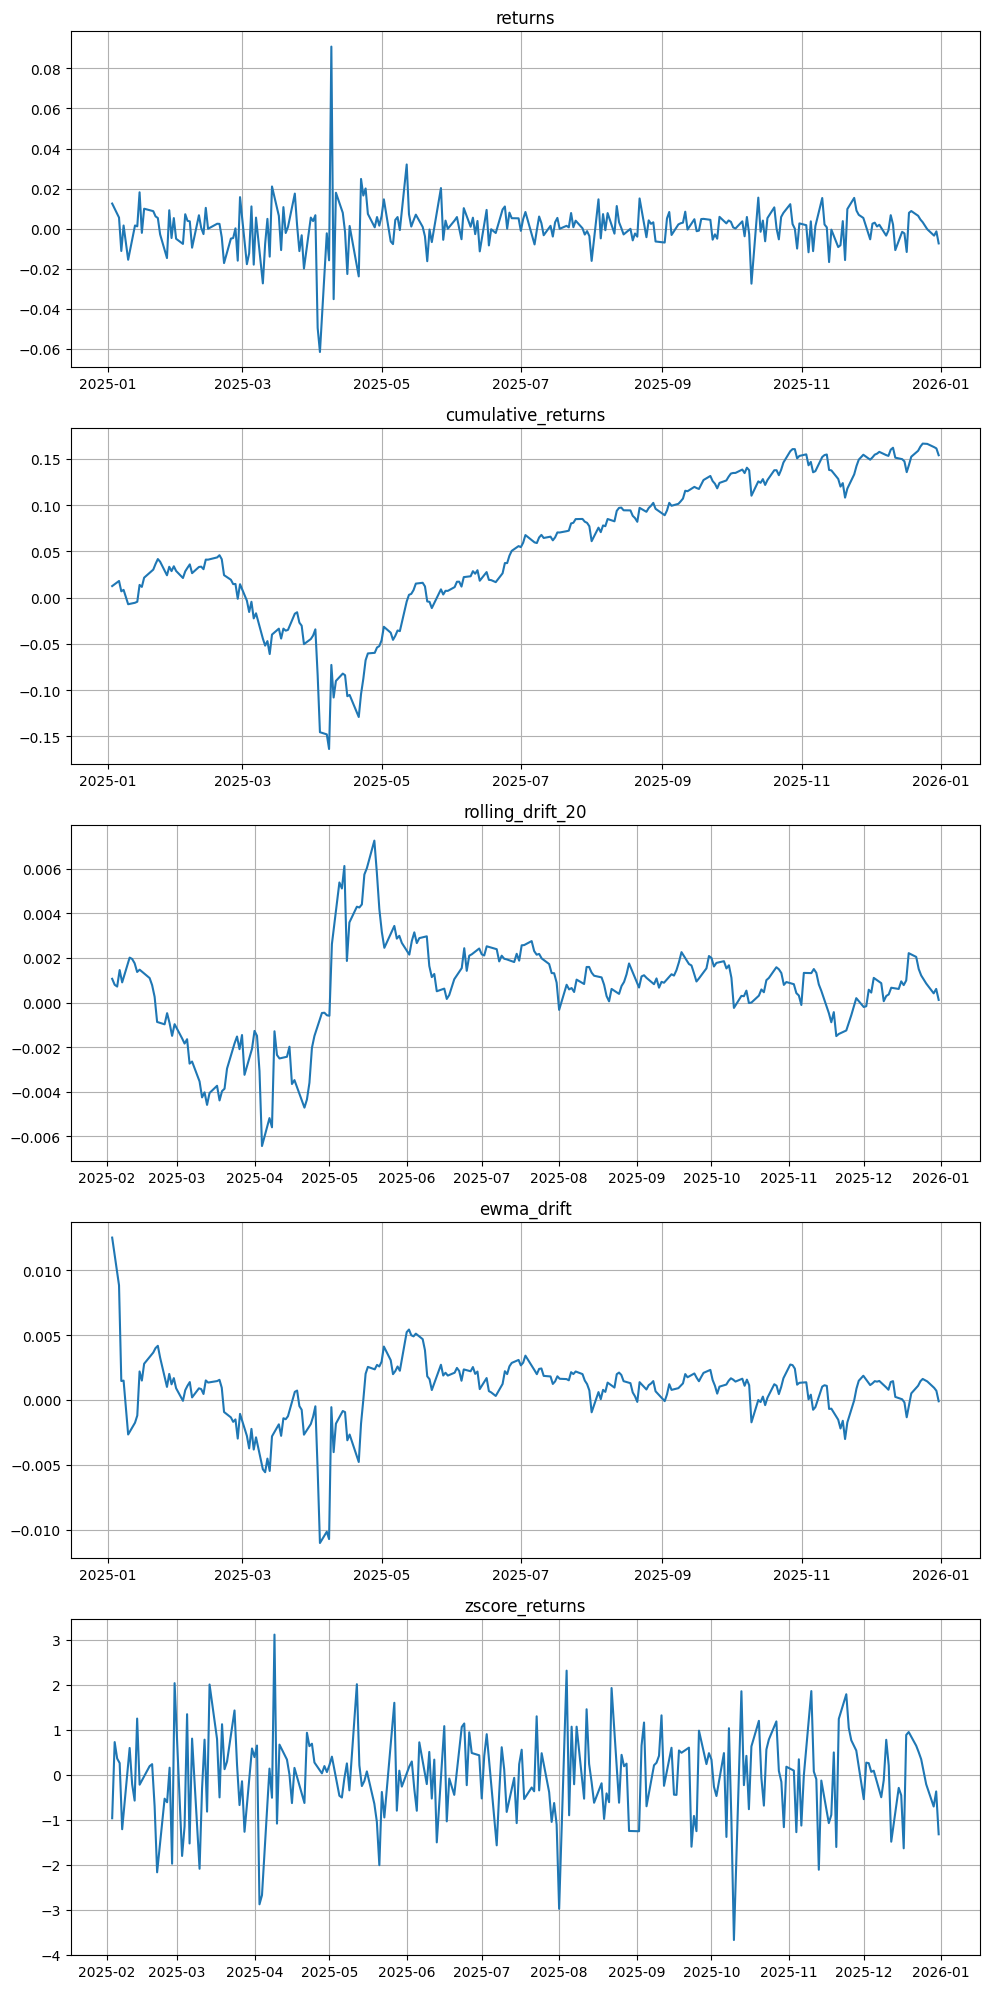

Volatility: Ticker
^GSPC    0.011769
dtype: float64

returns
Ticker       ^GSPC
count   249.000000
mean      0.000618
std       0.011769
min      -0.061609
25%      -0.003702
50%       0.001326
75%       0.005783
max       0.090895

rolling_volatility
Ticker       ^GSPC
count   230.000000
mean      0.010036
std       0.006815
min       0.003653
25%       0.006282
50%       0.008130
75%       0.010092
max       0.031849

ewma_volatility
Ticker       ^GSPC
count   249.000000
mean      0.007486
std       0.004015
min       0.003052
25%       0.005105
50%       0.006146
75%       0.008402
max       0.024762

volatility_ratio
Ticker  ^GSPC
count     0.0
mean      NaN
std       NaN
min       NaN
25%       NaN
50%       NaN
75%       NaN
max       NaN

vix_like_index
Ticker       ^GSPC
count   220.000000
mean     16.502439
std      10.335332
min       6.677951
25%      10.277545
50%      12.917431
75%      16.685478
max      42.319225

volatility_zscore
Ticker       ^GSPC
count   230.000000
m

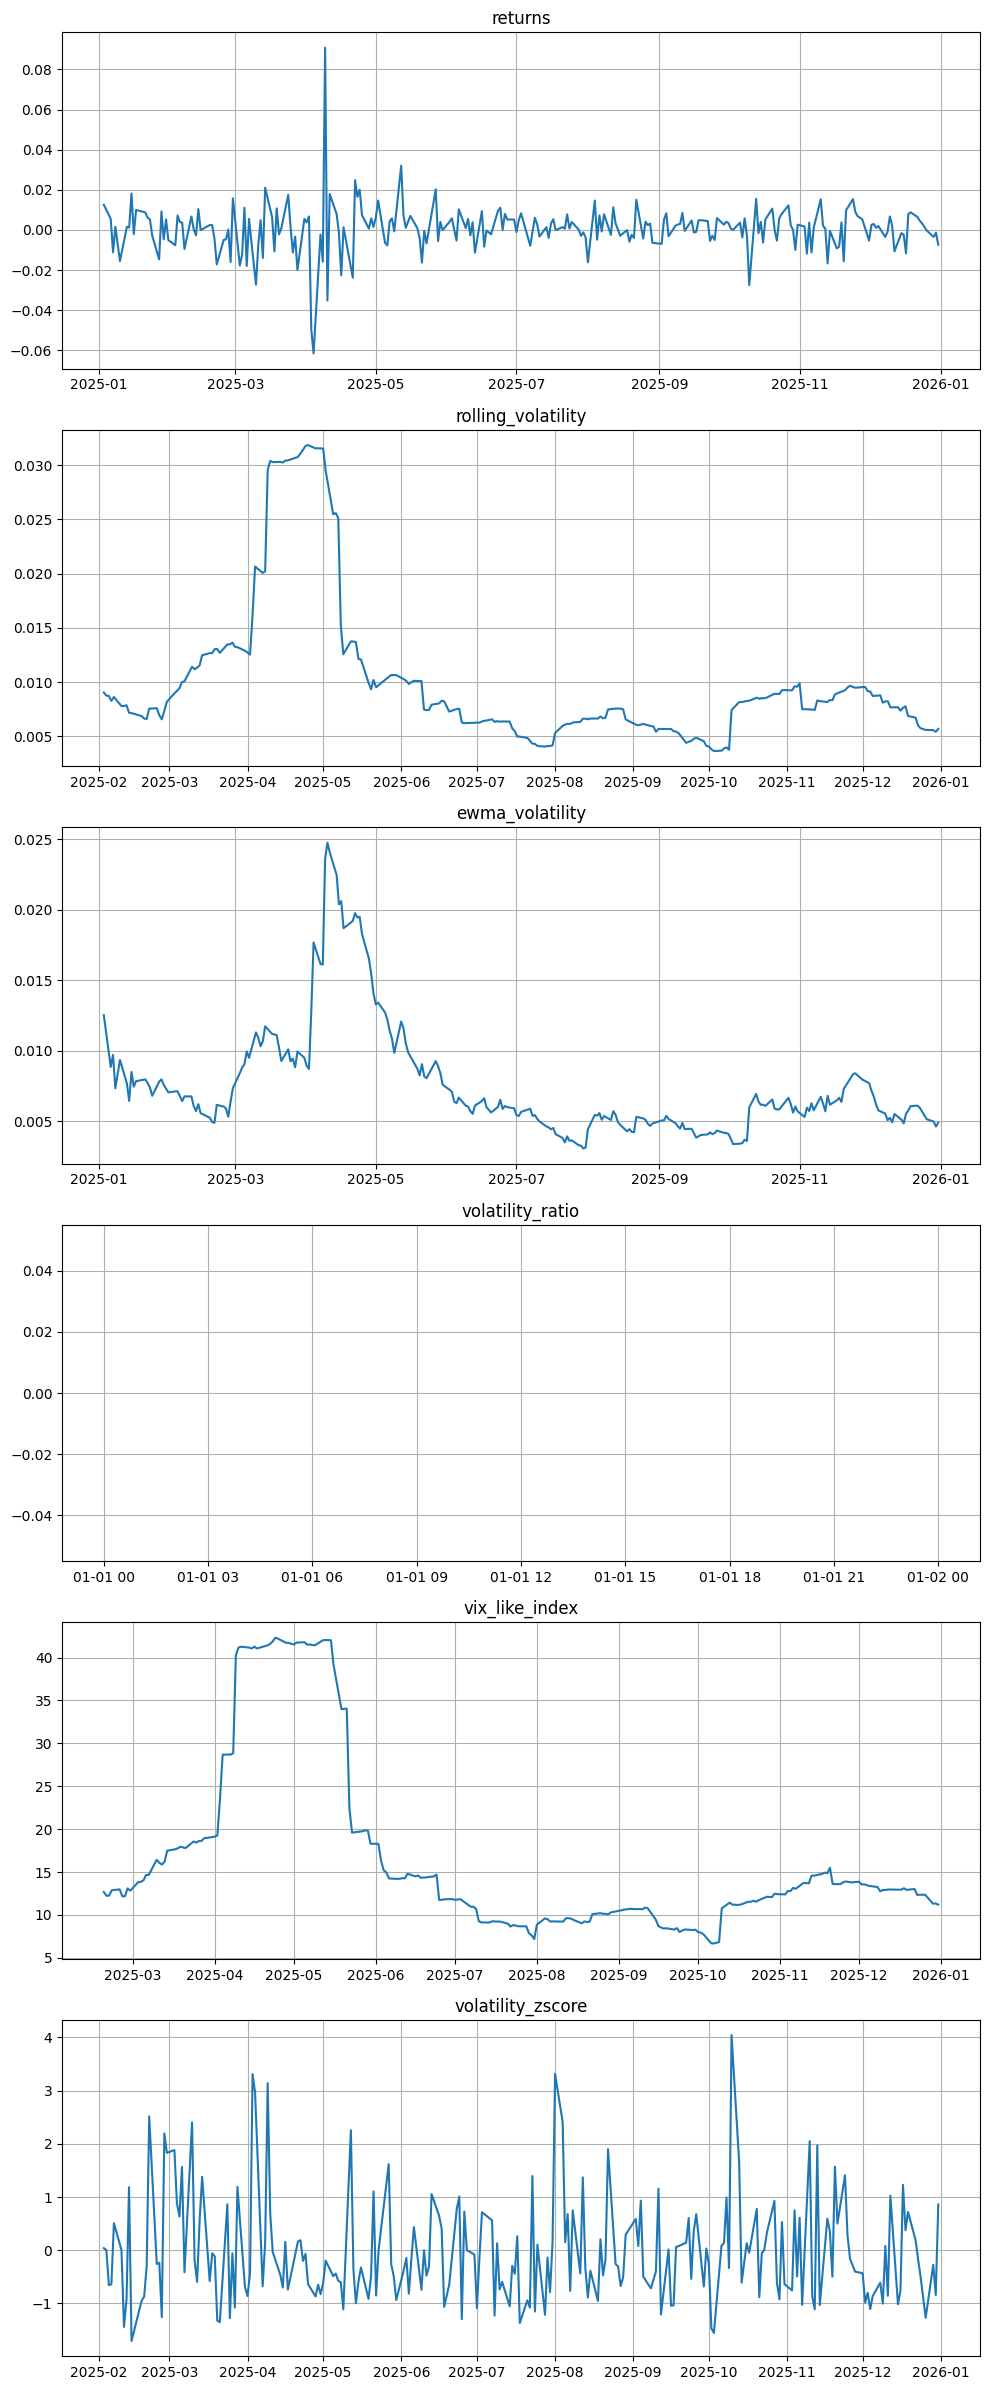

Average Volume: Ticker
^GSPC    5.123939e+09
dtype: float64

volume
Ticker         ^GSPC
count   2.500000e+02
mean    5.123939e+09
std     9.618487e+08
min     1.798270e+09
25%     4.629625e+09
50%     5.024145e+09
75%     5.456758e+09
max     9.489600e+09

rolling_volume
Ticker         ^GSPC
count   2.310000e+02
mean    5.194373e+09
std     3.792048e+08
min     4.431969e+09
25%     4.914587e+09
50%     5.197306e+09
75%     5.541029e+09
max     5.917912e+09

volume_zscore
Ticker       ^GSPC
count   231.000000
mean      0.047429
std       1.101084
min      -3.407654
25%      -0.734346
50%      -0.084471
75%       0.588354
max       3.812717

volume_acceleration
Ticker         ^GSPC
count   2.480000e+02
mean   -3.780645e+05
std     1.585648e+09
min    -9.538510e+09
25%    -5.973925e+08
50%     1.544500e+07
75%     6.115025e+08
max     4.798820e+09


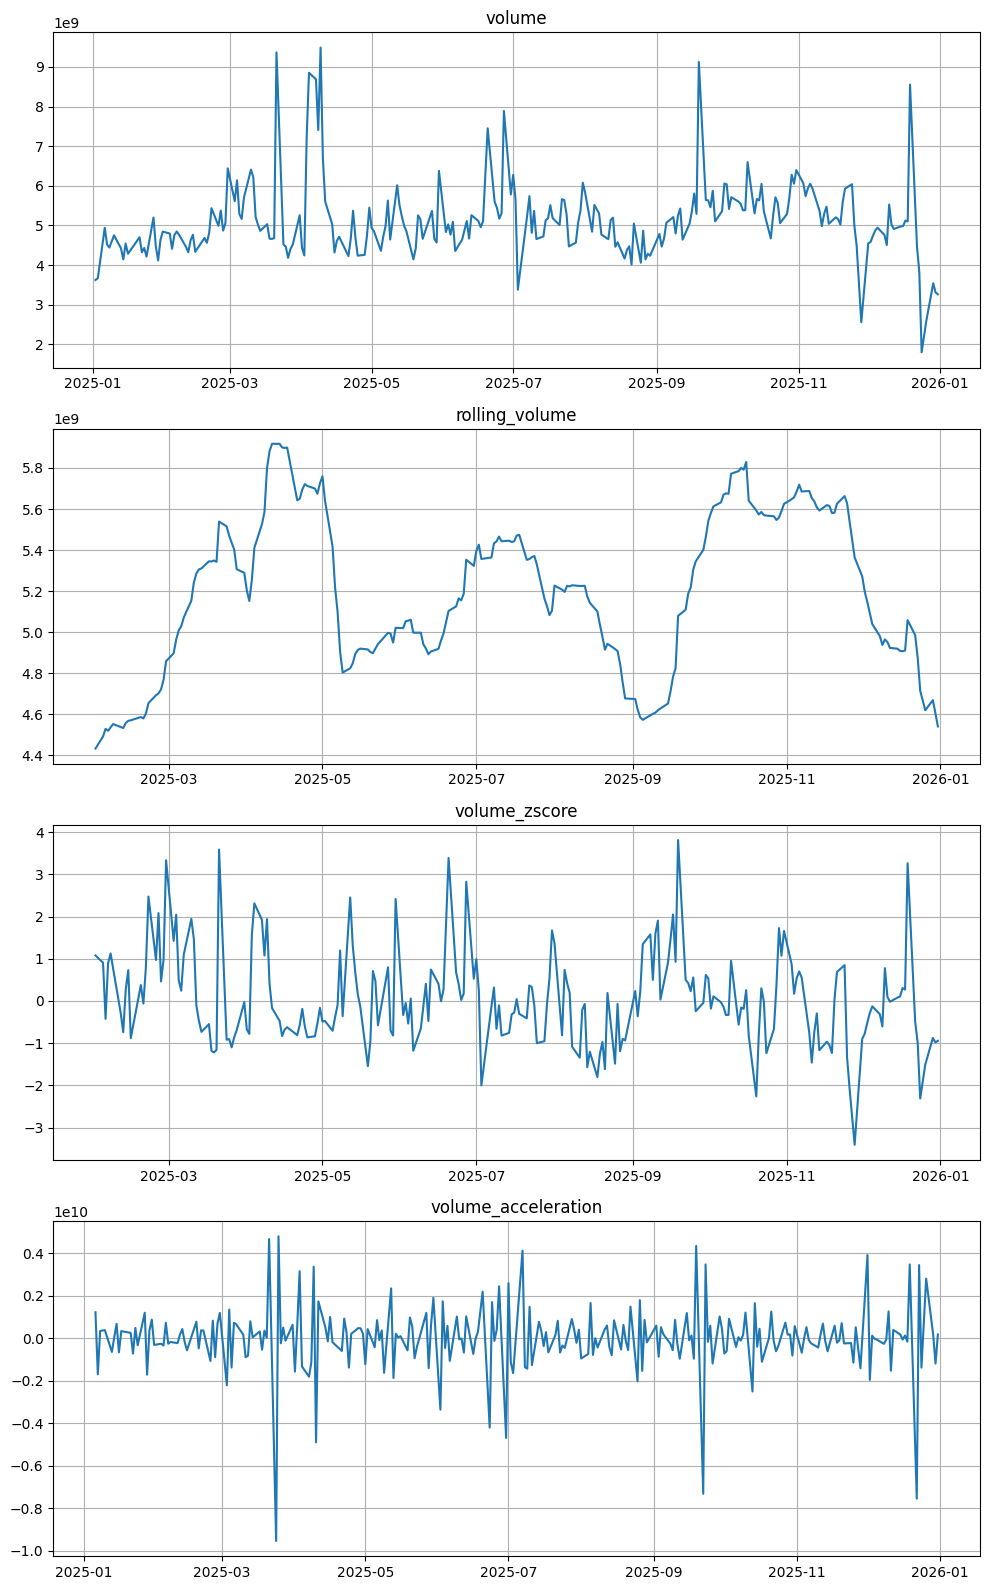

Average Illiquidity: Ticker
^GSPC    1.389055e-12
dtype: float64

amihud_illiquidity
Ticker         ^GSPC
count   2.300000e+02
mean    1.383365e-12
std     6.447150e-13
min     5.975629e-13
25%     9.883342e-13
50%     1.162483e-12
75%     1.514387e-12
max     3.470331e-12

price_impact
Ticker         ^GSPC
count   2.490000e+02
mean    9.202098e-10
std     1.131906e-08
min    -3.806273e-08
25%    -4.830909e-09
50%     1.518726e-09
75%     7.108036e-09
max     4.996311e-08

volume_volatility_ratio
Ticker         ^GSPC
count   2.300000e+02
mean    6.662681e+11
std     2.865673e+11
min     1.793658e+11
25%     4.953945e+11
50%     6.421561e+11
75%     8.139307e+11
max     1.536304e+12

liquidity_zscore
Ticker       ^GSPC
count   231.000000
mean      0.047429
std       1.101084
min      -3.407654
25%      -0.734346
50%      -0.084471
75%       0.588354
max       3.812717


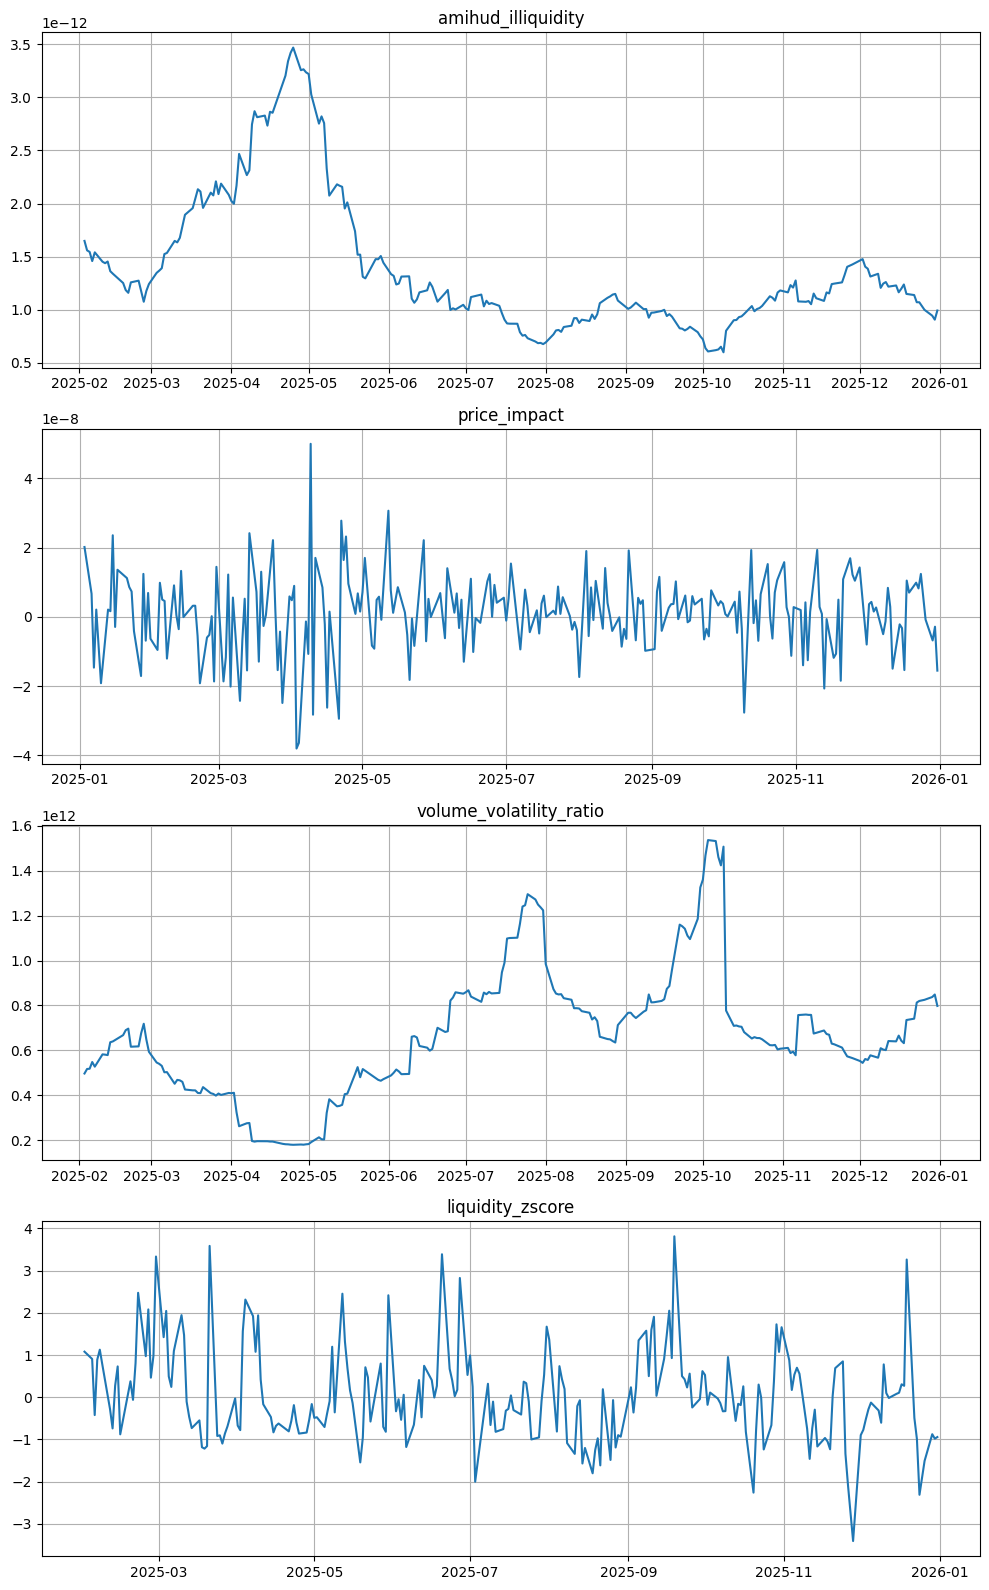

Correlation with Benchmark: 1.0

rolling_correlation
count    2.200000e+02
mean     1.000000e+00
std      5.317250e-15
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: ^GSPC, dtype: float64

correlation_zscore
count    200.000000
mean            NaN
std             NaN
min            -inf
25%       -1.695455
50%       -0.626126
75%        0.770742
max             inf
Name: ^GSPC, dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


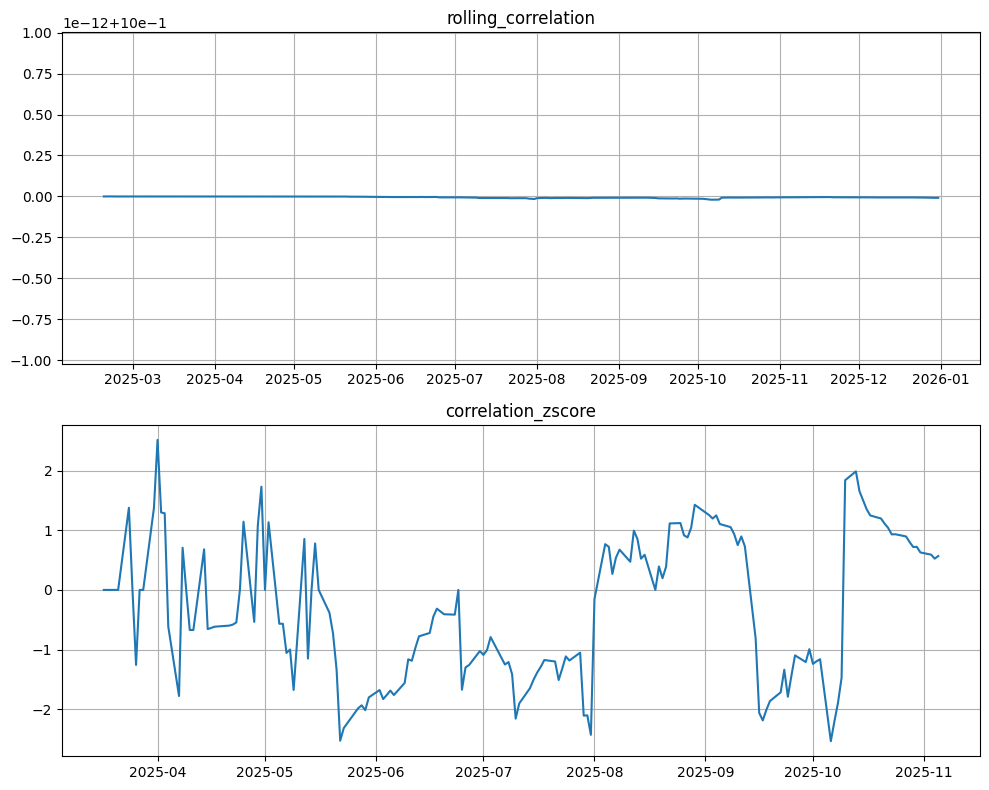

In [ ]:
prices = df["Close"]
volume = df["Volume"]

sp500 = prices

drift = Drift(prices)
drift.analyze()

vol = Volatility(prices)
vol.analyze()

volu = Volume(prices, volume)
volu.analyze()

liq = Liquidity(prices, volume)
liq.analyze()

corr = Correlation(prices, sp500)
corr.analyze()

This plot shows the returns of the asset over time to visualize drift, along with points where the direction of returns changes. The line represents the return values across the time period, while the highlighted scatter points mark moments where the sign of the returns switches from positive to negative or vice versa. The horizontal line at zero serves as a reference point separating positive and negative returns, making it easier to observe shifts in market direction and potential changes in trend.

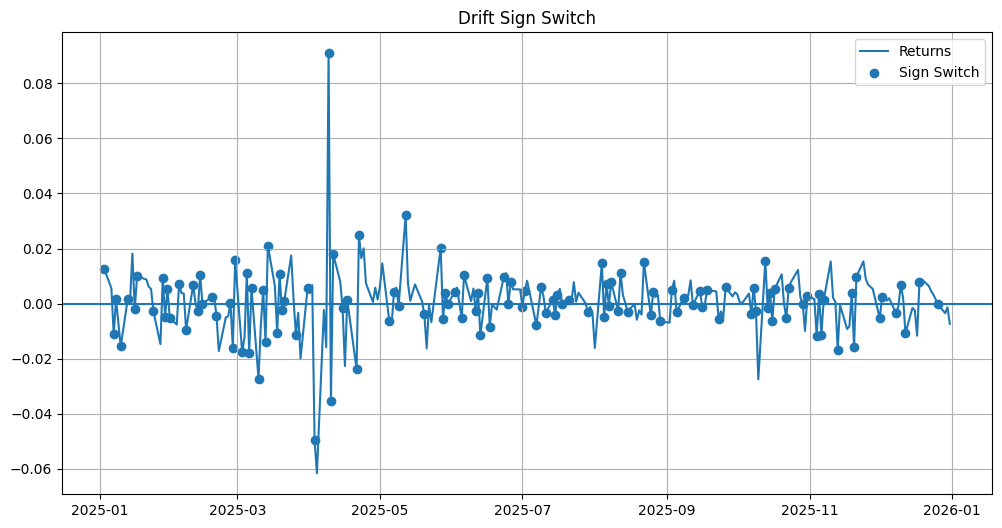

In [ ]:
#Plot drift sign-switch
drift = Drift(prices)

switches = drift.sign_change(drift.returns.squeeze())

plt.figure(figsize=(12,6))

plt.plot(drift.returns, label="Returns")

plt.scatter(
  drift.returns.index[switches],
  drift.returns[switches],
  label="Sign Switch"
)

plt.axhline(0)
plt.title("Drift Sign Switch")
plt.legend()
plt.grid(True)

plt.show()

This plot shows the cumulative drift of returns over time, representing the total accumulated movement of the asset. The blue line displays the cumulative sum of log returns, illustrating the overall growth or decline trend across the period. The red markers highlight points where the sign of returns switches, indicating potential changes in the market regime or momentum. The horizontal reference line at zero helps distinguish periods of overall positive versus negative cumulative performance.

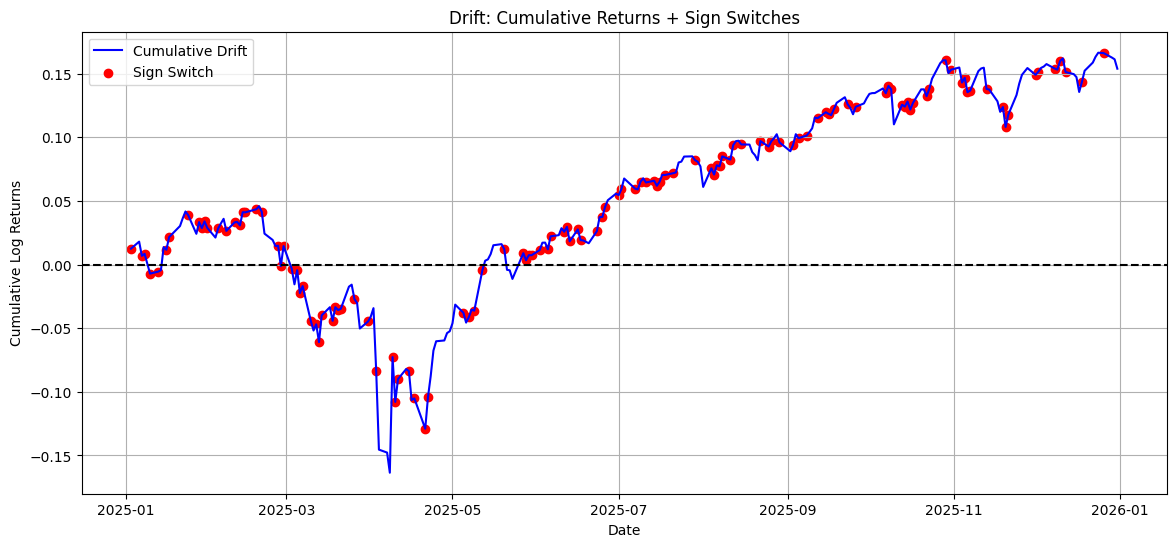

In [ ]:
# Drift Regime and Cumulative Drift
drift = Drift(prices)

returns = drift.returns.squeeze()
sign_switch = drift.sign_change(returns)

cumulative = returns.cumsum()

plt.figure(figsize=(14,6))
plt.plot(cumulative, label="Cumulative Drift", color="blue")
plt.scatter(
  cumulative.index[sign_switch],
  cumulative[sign_switch],
  color="red",
  marker="o",
  label="Sign Switch"
)
plt.title("Drift: Cumulative Returns + Sign Switches")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Returns")
plt.legend()
plt.grid(True)
plt.show()

This plot illustrates short-term volatility and how it compares to longer-term market volatility. The rolling 20-day volatility line shows recent fluctuations in returns, highlighting periods of increased or decreased market turbulence. The volatility ratio compares short-term volatility to the 252-day long-term baseline, helping identify when current market conditions are unusually volatile or relatively calm compared to historical levels.

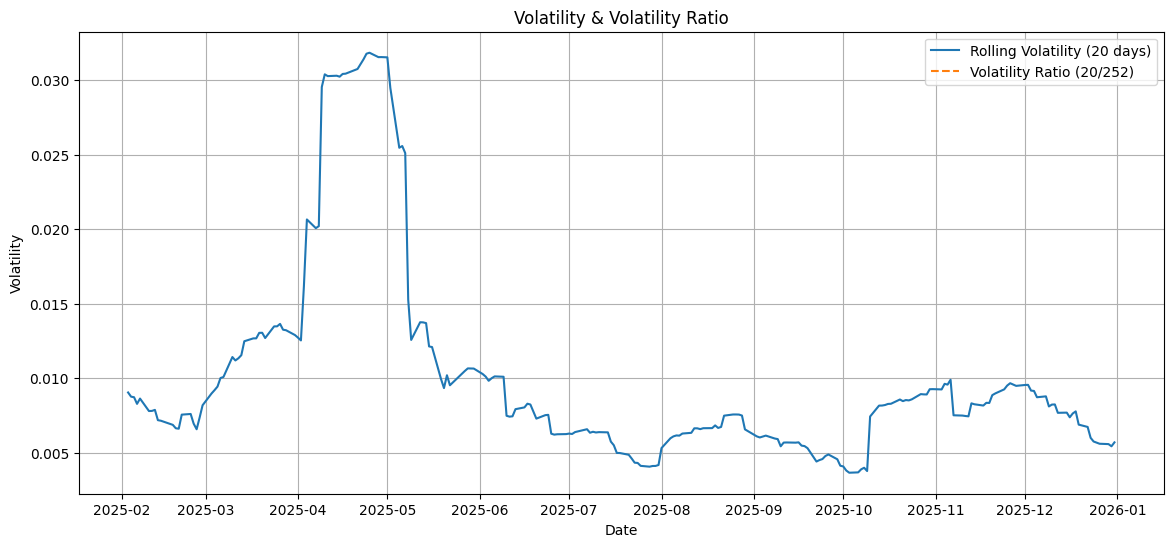

In [ ]:
vol = Volatility(prices)

# Rolling volatility and volatility ratio
rolling_vol = vol.returns.rolling(20).std()
long_vol = vol.returns.rolling(252).std()
vol_ratio = rolling_vol / long_vol

plt.figure(figsize=(14,6))
plt.plot(rolling_vol, label="Rolling Volatility (20 days)")
plt.plot(vol_ratio, label="Volatility Ratio (20/252)", linestyle="--")
plt.title("Volatility & Volatility Ratio")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

This plot shows trading volume over time along with a standardized measure of unusual activity. The main line represents the raw volume traded during each period, while the dashed line shows the volume z-score scaled by the mean, highlighting when trading activity is significantly higher or lower than its recent average. This helps identify abnormal spikes or drops in market participation that may signal increased interest or important market events.

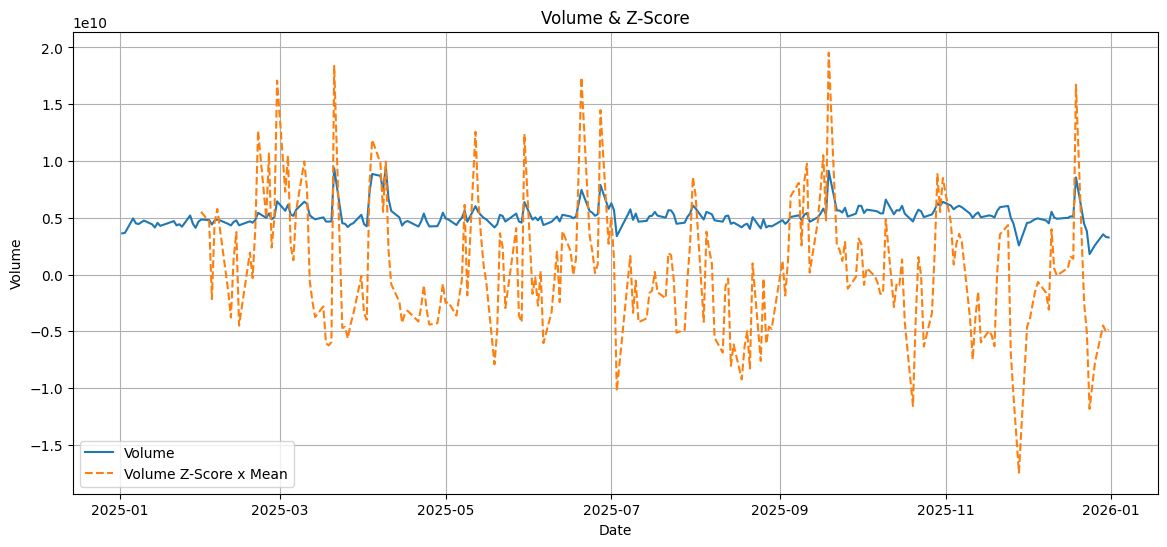

In [ ]:
volu = Volume(prices, volume)
#Volume with volume z-score
vol_series = volu.volume.squeeze()
vol_z = volu.rolling_zscore(vol_series, 20)

plt.figure(figsize=(14,6))
plt.plot(vol_series, label="Volume")
plt.plot(vol_z * vol_series.mean(), label="Volume Z-Score x Mean", linestyle="--")
plt.title("Volume & Z-Score")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.show()

This plot displays the Amihud Illiquidity measure, which captures how much price changes relative to trading volume. Higher values indicate lower liquidity, meaning that small amounts of trading volume cause larger price movements. This helps identify periods of liquidity stress where the market becomes less efficient and trades have a greater price impact.

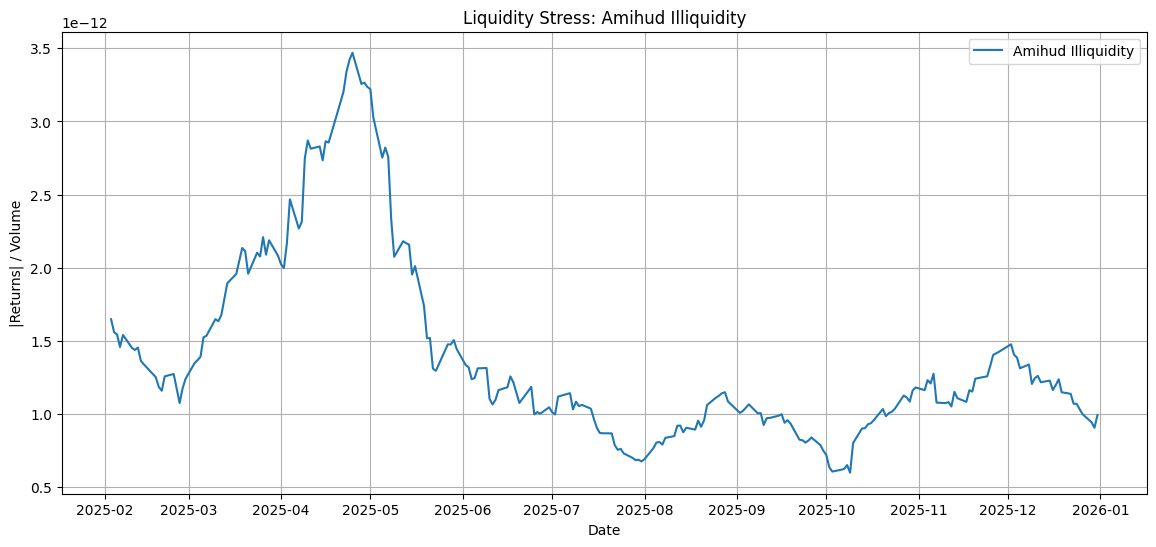

In [ ]:
liq = Liquidity(prices, volume)
#Liquidity
amihud = liq.amihud_illiquidity(20)

plt.figure(figsize=(14,6))
plt.plot(amihud, label="Amihud Illiquidity")
plt.title("Liquidity Stress: Amihud Illiquidity")
plt.xlabel("Date")
plt.ylabel("|Returns| / Volume")
plt.legend()
plt.grid(True)
plt.show()

This scatter plot shows the relationship between rolling volatility and trading volume. Each point represents a time period where volatility and volume are plotted against each other to observe how market activity relates to price fluctuations. The color scale highlights different volatility levels, helping reveal patterns where higher volatility often coincides with increased trading activity.

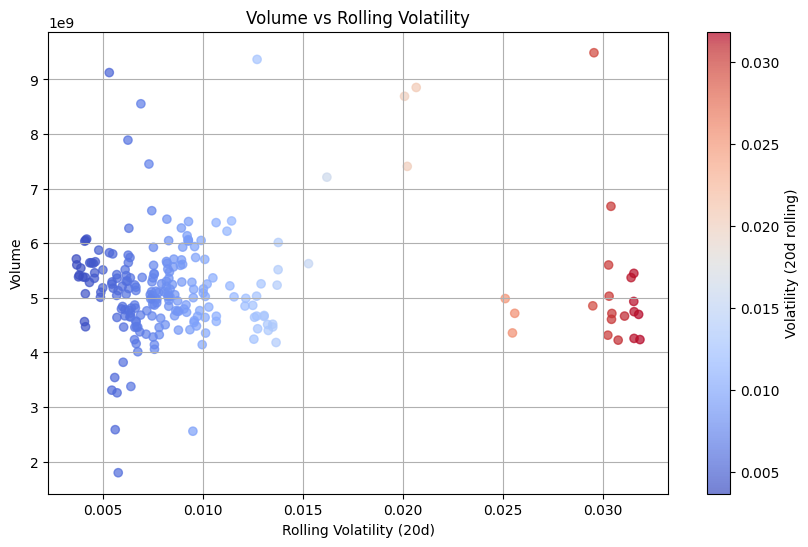

In [ ]:
#Volatility vs volume scatter
# Align rolling volatility and volume
df_scatter = pd.concat([rolling_vol, vol_series], axis=1).dropna()
df_scatter.columns = ["volatility", "volume"]

plt.figure(figsize=(10,6))
plt.scatter(
  df_scatter["volatility"],
  df_scatter["volume"],
  c=df_scatter["volatility"],
  cmap="coolwarm",
  alpha=0.7
)
plt.colorbar(label="Volatility (20d rolling)")
plt.xlabel("Rolling Volatility (20d)")
plt.ylabel("Volume")
plt.title("Volume vs Rolling Volatility")
plt.grid(True)
plt.show()

This scatter plot examines the relationship between volatility and market liquidity. Each point represents a time period where rolling volatility is compared with the Amihud illiquidity measure. The color scale highlights different levels of illiquidity, helping reveal how periods of higher volatility are often associated with lower liquidity and greater price impact from trades.

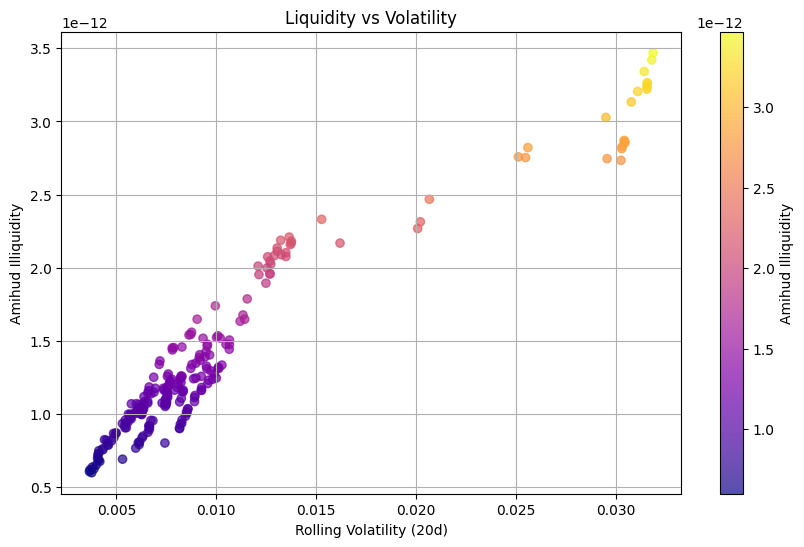

In [ ]:
#Liquidity vs Volatility scatter
# Align rolling volatility and amihud
df = pd.concat([rolling_vol, amihud], axis=1).dropna()
df.columns = ["vol", "illiquidity"]

plt.figure(figsize=(10,6))
plt.scatter(
  df["vol"],
  df["illiquidity"],
  c=df["illiquidity"],
  cmap="plasma",
  alpha=0.7
)
plt.colorbar(label="Amihud Illiquidity")
plt.xlabel("Rolling Volatility (20d)")
plt.ylabel("Amihud Illiquidity")
plt.title("Liquidity vs Volatility")
plt.grid(True)
plt.show()

This analysis constructs a composite market stability index by combining multiple normalized market metrics: drift, volatility, volume, illiquidity, and correlation. Each metric is standardized using a z-score and weighted to reflect its contribution to overall market conditions. Illiquidity is inverted so that higher values represent better liquidity, and the weighted metrics are summed to produce a single composite index representing overall market stability.

To further analyze market dynamics, a two-state Markov Switching Model is applied to the composite index. This model identifies different market regimes over time, distinguishing between periods with different statistical characteristics. The resulting visualization highlights when the market transitions between regimes, helping reveal shifts between more stable and more stressed market environments. Finally, the average values of the underlying metrics are compared across regimes to better understand the characteristics of each market state.

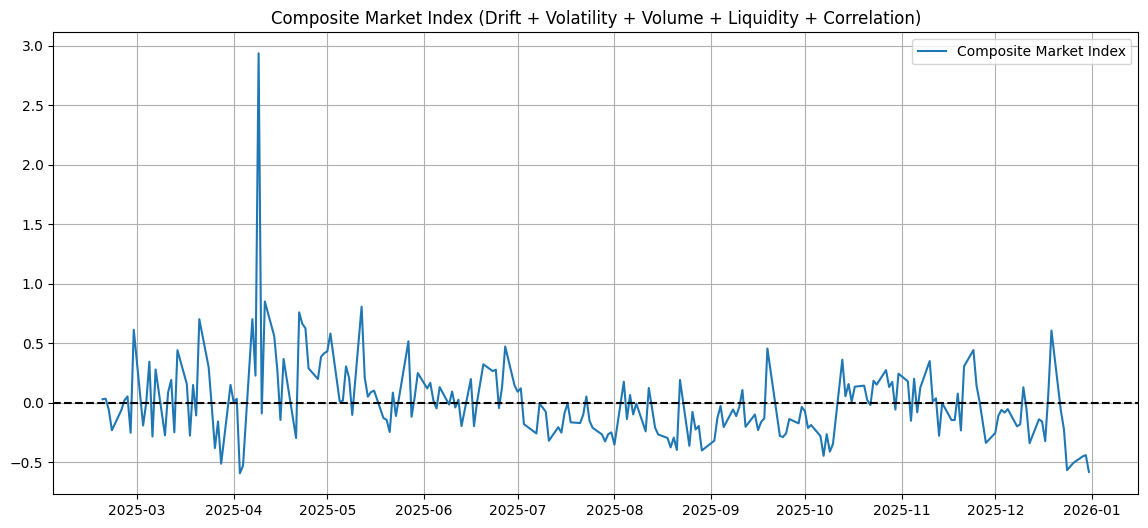

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:        composite_index   No. Observations:                  220
Model:               MarkovRegression   Log Likelihood                 -24.568
Date:                Tue, 10 Mar 2026   AIC                             61.135
Time:                        20:12:33   BIC                             81.497
Sample:                             0   HQIC                            69.358
                                - 220                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0520      0.017     -2.995      0.003      -0.086      -0.018
sigma2         0.0534      0.006      8.859      0.0

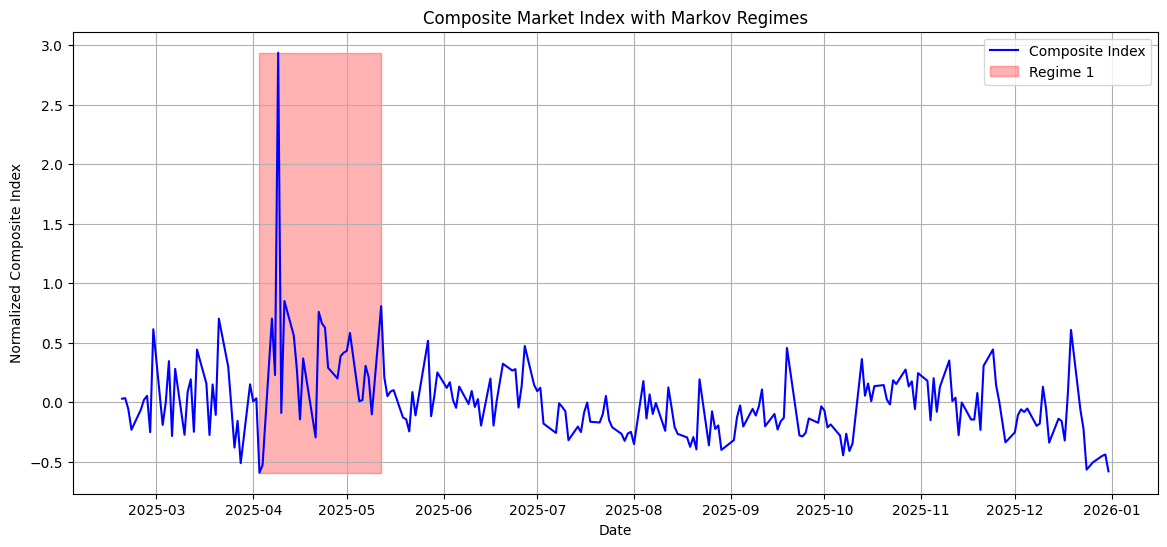

           drift  volatility        volume   illiquidity  correlation
regime                                                               
0       0.000429    0.007814  5.159894e+09  1.175916e-12          1.0
1       0.001114    0.026632  5.570286e+09  2.830804e-12          1.0


In [ ]:
#------------>Create stability Index


# Make sure all series are Series and aligned
# Drift
returns = Drift(prices).returns
if isinstance(returns, pd.DataFrame):
    returns = returns.squeeze()

# Rolling Volatility
rolling_vol = Volatility(prices).returns.rolling(20).std()
if isinstance(rolling_vol, pd.DataFrame):
    rolling_vol = rolling_vol.squeeze()

# Volume
vol_series = Volume(prices, volume).volume
if isinstance(vol_series, pd.DataFrame):
    vol_series = vol_series.squeeze()

# Amihud liquidity
amihud = Liquidity(prices, volume).amihud_illiquidity(20)
if isinstance(amihud, pd.DataFrame):
    amihud = amihud.squeeze()

# Rolling correlation
rolling_corr = Correlation(prices, sp500).rolling_correlation(30)
if isinstance(rolling_corr, pd.DataFrame):
    rolling_corr = rolling_corr.squeeze()

# Combine all into a single DataFrame
df_metrics = pd.concat([
  returns.rename("drift"),
  rolling_vol.rename("volatility"),
  vol_series.rename("volume"),
  amihud.rename("illiquidity"),
  rolling_corr.rename("correlation")
], axis=1).dropna()

df_metrics.head()

weights = pd.Series({
    "drift":0.25,
    "volatility":0.25,
    "volume":0.15,
    "illiquidity":0.20,
    "correlation":0.15
})

#Normalize z-score all metrics
df_norm = (df_metrics - df_metrics.mean()) / df_metrics.std()

df_norm["illiquidity"] = -df_norm["illiquidity"]

# Composite index: simple sum of normalized metrics
df_norm["composite_index"] = df_norm[weights.index].mul(weights).sum(axis=1)

plt.figure(figsize=(14,6))
plt.plot(df_norm["composite_index"], label="Composite Market Index")
plt.title("Composite Market Index (Drift + Volatility + Volume + Liquidity + Correlation)")
plt.axhline(0, color="black", linestyle="--")
plt.grid(True)
plt.legend()
plt.show()


from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# Fit 2-state Markov Switching Model on composite index
model = MarkovRegression(
  df_norm["composite_index"],
  k_regimes=2,
  trend="c",
  switching_variance=True
)

fit_model = model.fit()
print(fit_model.summary())

regime_probs = fit_model.smoothed_marginal_probabilities
regime_probs.head()

plt.figure(figsize=(14,6))
plt.plot(df_norm["composite_index"], label="Composite Index", color="blue")

# Shade regions by regime 1
plt.fill_between(
    df_norm.index,
    df_norm["composite_index"].min(),
    df_norm["composite_index"].max(),
    where=regime_probs[1] > 0.5,
    color="red",
    alpha=0.3,
    label="Regime 1"
)

plt.title("Composite Market Index with Markov Regimes")
plt.xlabel("Date")
plt.ylabel("Normalized Composite Index")
plt.legend()
plt.grid(True)
plt.show()


df_metrics["regime"] = (regime_probs[1] > 0.5).astype(int)

# Print average metrics by regime
print(df_metrics.groupby("regime").mean())

The Markov Switching Model identifies two different market regimes based on the composite index.

Regime 0 represents a more stable market environment. The average volatility is relatively low (0.0078), drift is small, and illiquidity is lower, meaning prices move smoothly and trading has less price impact. The transition probability
p[0->0]=0.994 shows that once the market is in this regime, it tends to remain stable for long periods.

Regime 1 represents a more volatile or stressed market state. In this regime, volatility (0.0266) and illiquidity are significantly higher, meaning prices fluctuate more and trades have a larger impact on price. Drift is also slightly higher, suggesting stronger directional movements during these periods.

Overall, the results indicate that the market spends most of its time in the stable regime, but occasionally shifts into a higher volatility and lower liquidity regime, which corresponds to periods of increased market stress or uncertainty.